<a href="https://colab.research.google.com/github/virenmarcellya12/Project-Pemro/blob/main/Tugas_Praktikum_Minggu_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [69]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1047)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5*47
beta0 = 10 +47
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


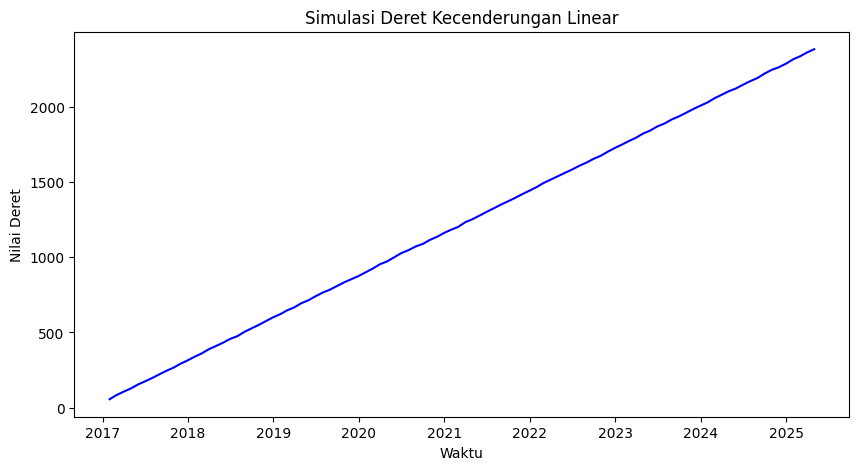

In [70]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

Berdasarkan plot deret waktu, terlihat bahwa nilai pengamatan cenderung meningkat secara teratur dari waktu ke waktu. Hal ini menunjukkan adanya kemungkinan korelasi positif antar pengamatan. Artinya, nilai pada suatu periode cenderung berkaitan dengan nilai pada periode sebelumnya. Untuk memastikan apakah nilai pada suatu periode berkorelasi dengan nilai pada periode sebelumnya, dilakukan pengecekan menggunakan autokorelasi.

In [71]:
# mengecek autokorelasi pada lag 1
autocorr_lag1 = df["Value"].autocorr(lag=1)

print(f"Autokorelasi lag 1: {autocorr_lag1:.4f}")

Autokorelasi lag 1: 1.0000


Nilai autokorelasi pada lag 1 sebesar 1.0000 menunjukkan adanya korelasi positif yang sangat kuat antara nilai deret pada periode sekarang dengan nilai pada satu periode sebelumnya.


In [72]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [73]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.562e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.68e-246
Time:                        16:18:56   Log-Likelihood:                -219.45
No. Observations:                 100   AIC:                             442.9
Df Residuals:                      98   BIC:                             448.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           57.2340      0.435    131.426   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

Hasil pengepasan model menghasilkan nilai intersep sebesar 57,2340 dan koefisien waktu sebesar 23,5007. Nilai tersebut sangat dekat dengan nilai parameter asli, yaitu beta 0=57 dan beta1=23,5. Oleh karena itu, dapat disimpulkan bahwa model regresi mampu mengestimasi paremeter asli dengan baik.

Apakah model regresi yang dipaskan sudah bagus?

Model regresi yang diperoleh dapat dikatakan sudah bagus. Nilai R^2 sebesar 1.0000 menunjukkan bahwa hampir seluruh perubahan nilai deret dapat dijelaskan oleh waktu. Koefisien waktu memiliki nilai p-value < 0,05, artinya koefisien waktu signifikan. Selain itu, nilai Durbin-Watson mendekati 2 yaitu sebesar 1,874, hal ini menunjukkan bahwa tidak terdapat autokorelasi yang kuat pada residual model.

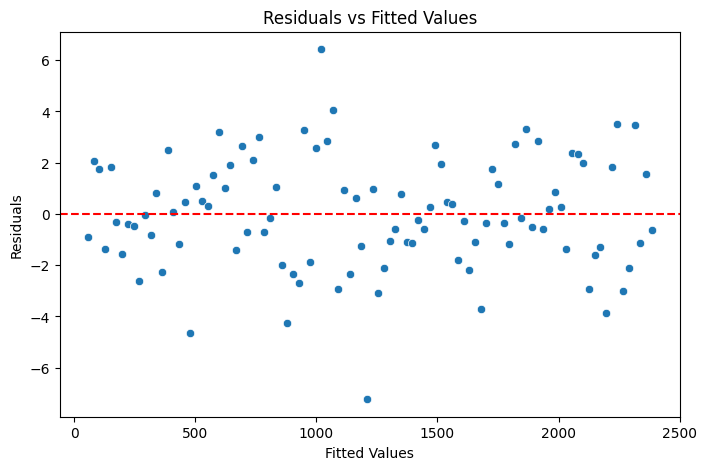

In [74]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

Berdasarkan plot Residuals vs Fitted Values, titik-titik residual terlihat menyebar secara acak di sekitar garis nol dan tidak membentuk pola tertentu. Hal ini menunjukkan bahwa hubungan linear pada model sudah cukup sesuai. Selain itu, sebaran residual juga relatif sama pada setiap nilai prediksi dan tidak membentuk pola melebar atau menyempit. Pada plot tersebut terdapat beberapa titik yang cukup jauh dari garis nol tetapi secara keseluruhan masih menunjukkan pola yang acak.

In [75]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.7396


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

H0 : asumsi homoskedastisitas terpenuhi
H1 : asumsi homoskedastisitas tidak terpenuhi

Berdasarkan uji Breusch-Pagan diperoleh nilai p-value sebesar 0,7396 > 0,05, maka gagal menolak H0. Artinya, tidak terdapat cukup bukti adanya heteroskedastisitas, sehingga asumsi homoskedastisitas terpenuhi.

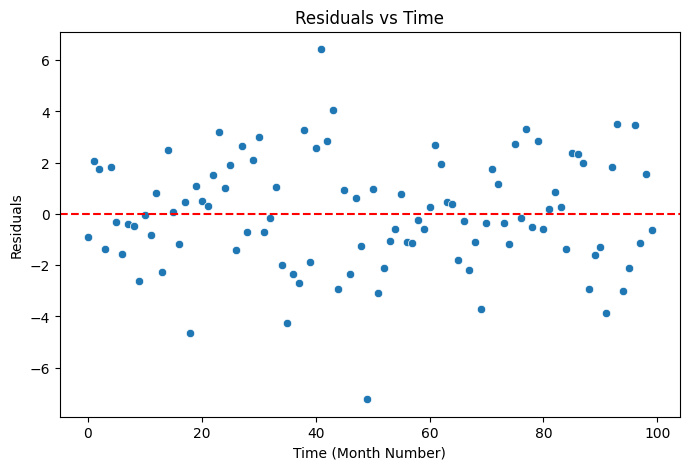

In [76]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

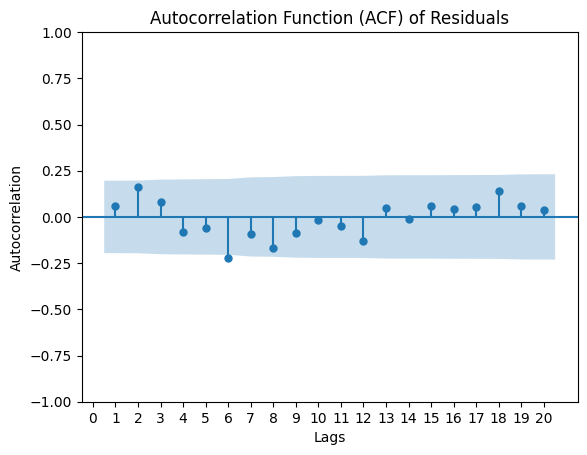

In [77]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

Berdasarkan plot ACF residual, sebagian besar nilai autokorelasi berada di dalam batas kepercayaan, ini menunjukkan bahwa tidak terdapat autokorelasi yang signifikan pada residual. Namun, pada lag 6 terlihat satu nilai yang sedikit melewati batas bawah selang kepercayaan, sehingga secara keseluruhan residual masih menunjukkan pola yang cukup acak. Oleh karena itu, asumsi tidak adanya autokorelasi pada residual terpenuhi.


In [78]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.389569   0.532526
2    3.114069   0.210760
3    3.837632   0.279539
4    4.559952   0.335498
5    4.971289   0.419394
6   10.402436   0.108696
7   11.362174   0.123583
8   14.442240   0.070942
9   15.245652   0.084406
10  15.275917   0.122322
11  15.533774   0.159341
12  17.551924   0.129988
13  17.796438   0.165403
14  17.812866   0.215437
15  18.259902   0.249248
16  18.456360   0.297859
17  18.791025   0.340658
18  21.214529   0.268728
19  21.693171   0.299792


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

H0: tidak terdapat autokorelasi pada residual
H1: terdapat autokorelasi pada residual

Berdasarkan uji Ljung-Box, seluruh nilai p-value pada lag 1 sampai dengan lag 19 lebih besar dari 0,05. Artinya, tidak terdapat cukup bukti adanya autokorelasi yang signifikan pada residual, sehingga asumsi tidak adanya autokorelasi pada model terpenuhi.

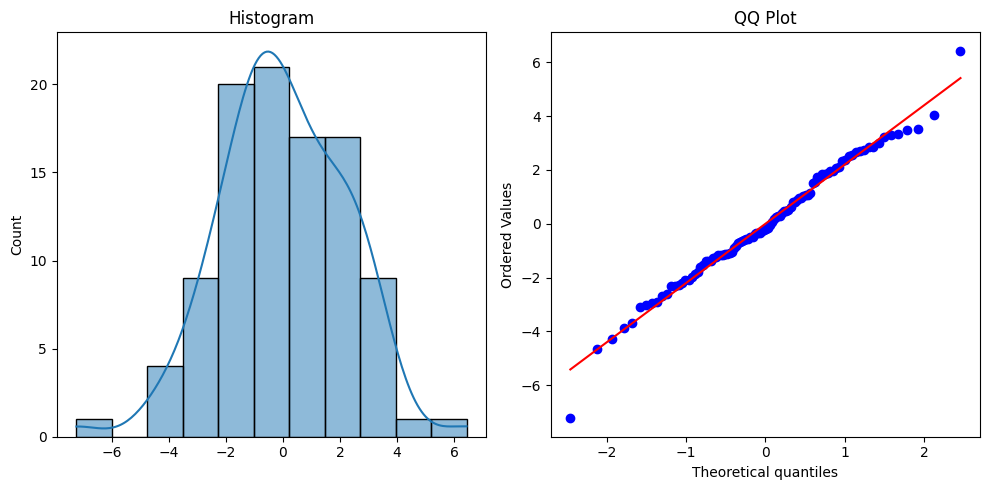

In [79]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

Berdasarkan histogram dan QQ Plot, residual terlihat cenderung mengikuti distribusi normal. Hal ini terlihat dari bentuk histogram yang cukup menyerupai distribusi normal dan sebagian besar titik pada QQ Plot berada di sekitar garis diagonal. Pada plot terdapat beberapa titik yang menyimpang pada bagian ujung, tetapi tidak terlihat penyimpangan yang cukup besar dari distribusi normal.

In [80]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9892854257904374, p-value = 0.6071579354614588


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

H0 : residual berdistribusi normal
H1 : residual tidak berdistribusi normal

Berdasarkan uji Shapiro-Wilk diperoleh p-value sebesar 0,6072 > 0,05, maka gagal tolak H0. Artinya, tidak terdapat cukup bukti bahwa residual menyimpang dari distribusi normal.
Sehingga dapat disimpulkan bahwa hasil dari uji ini sejalan dengan histogram dan QQ Plot, yang secara visual juga menunjukkan bahwa residual cenderung mengikuti distribusi normal.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [81]:
# Menentukan parameter simulasi
np.random.seed(1047)
n_periods = 120
beta_0, beta_1, beta_2= 50+47, 0.5*47, 0.02*47
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

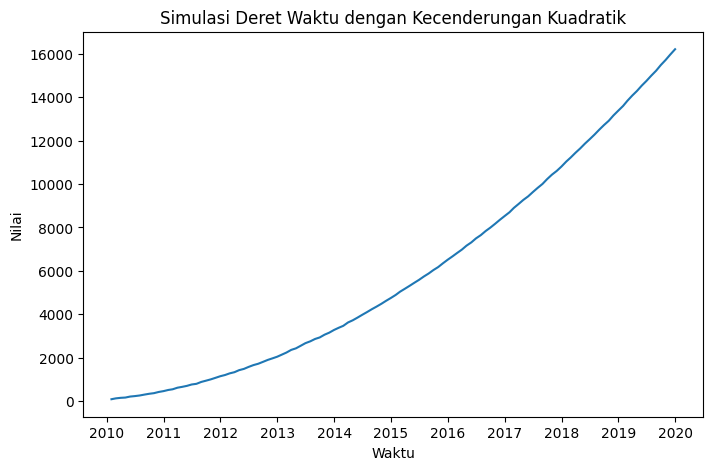

In [82]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

Berdasarkan plot, deret waktu menunjukkan kecenderungan meningkat dengan pola melengkung ke atas. Pada awal periode kenaikannya relatif kecil, kemudian semakin lama meningkat semakin cepat. Perbedaannya dengan pola kecenderungan linear adalah pada deret linear yang memiliki kenaikan relatif tetap dan membentuk garis lurus, sedangkan pada kecenderungan kuadratik memiliki kenaikan yang tidak tetap dan semakin besar dari waktu ke waktu sehingga membentuk pola melengkung.


In [83]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.209e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.13e-311
Time:                        16:18:57   Log-Likelihood:                -452.99
No. Observations:                 120   AIC:                             912.0
Df Residuals:                     117   BIC:                             920.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         97.8820      2.877     34.016      0.0

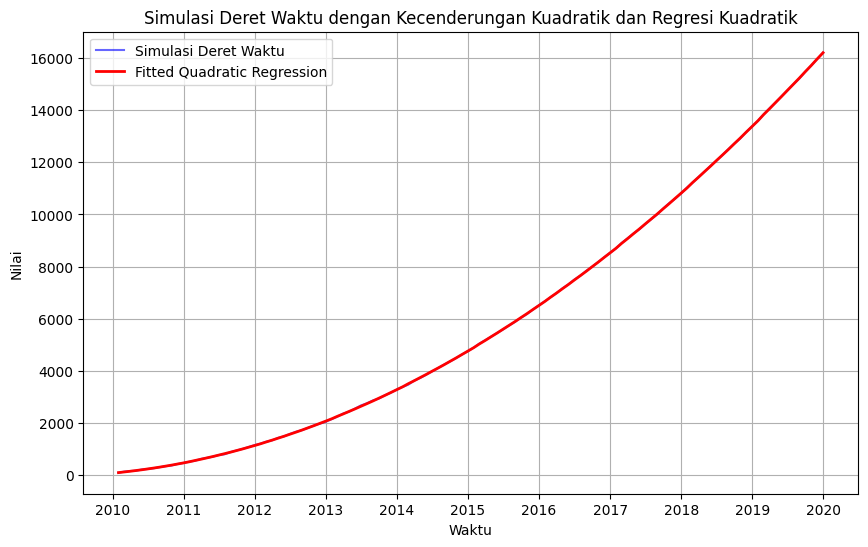

In [84]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Jawaban:

Berdasarkan hasil pemeriksaan residual, model regresi kuadratik dapat dikatakan sudah memenuhi asumsi-asumsi model. Plot Residuals vs Fitted Values menunjukkan residual menyebar di sekitar nol dan tidak membentuk pola yang jelas. Hasil uji Breusch-Pagan memberikan p-value sebesar 0,2339 > 0,05, sehingga asumsi homoskedastisitas terpenuhi. Plot ACF juga tidak menunjukkan autokorelasi yang kuat, dan hasil uji Ljung-Box pada lag 1 sampai 19 seluruhnya memiliki p-value lebih besar dari 0,05, sehingga tidak terdapat autokorelasi yang signifikan pada residual. Selain itu, histogram dan QQ Plot menunjukkan residual mendekati distribusi normal. Hal ini diperkuat oleh uji Shapiro-Wilk dengan p-value sebesar 0,5009 yang lebih besar dari 0,05, sehingga asumsi normalitas residual terpenuhi. Oleh karena itu, asumsi model regresi kuadratik telah terpenuhi.


Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

Jawaban:
Model regresi kuadratik yang dipaskan terhadap deret dapat dikatakan sudah tepat. Hal ini terlihat dari garis hasil regresi yang mampu mengikuti pola kecenderungan kuadratik pada data dengan baik. Selain itu, dari hasil pengecekan residual, asumsi homoskedastisitas, tidak adanya autokorelasi, dan normalitas residual juga terpenuhi. Oleh karena itu, model regresi kuadratik sesuai jika digunakan untuk menggambarkan pola deret waktu tersebut.

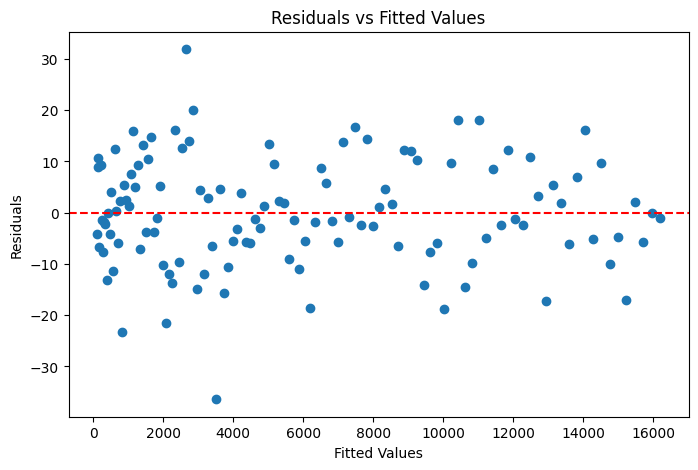

In [85]:
# cek asumsi model regresi kuadratik
plt.figure(figsize=(8,5))
plt.scatter(model_quad.fittedvalues, model_quad.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

Berdasarkan plot Residuals vs Fitted Values, titik-titik residual secara umum menyebar di sekitar garis nol dan tidak membentuk pola melengkung yang jelas. Hal ini menunjukkan bahwa bentuk model kuadratik sudah cukup sesuai dengan pola data. Namun, penyebaran residual terlihat agak lebih lebar pada nilai fitted yang rendah dibandingkan pada nilai fitted yang tinggi. Oleh karena itu, secara visual masih ada kemungkinan varians residual tidak sepenuhnya konstan, sehingga perlu dikonfirmasi dengan uji Breusch-Pagan.

In [86]:
#Uji Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model_quad.resid, model_quad.model.exog)
print(f"P-value Breusch-Pagan: {bp_test[1]:.4f}")

P-value Breusch-Pagan: 0.2339


H0 : asumsi homoskedastisitas terpenuhi

H1 : asumsi homoskedastisitas tidak terpenuhi

Berdasarkan uji Breusch-Pagan diperoleh p-value sebesar 0,2339 > 0,05, maka gagal menolak H0. Artinya, tidak terdapat cukup bukti adanya heteroskedastisitas, sehingga asumsi homoskedastisitas pada model dapat dikatakan terpenuhi.

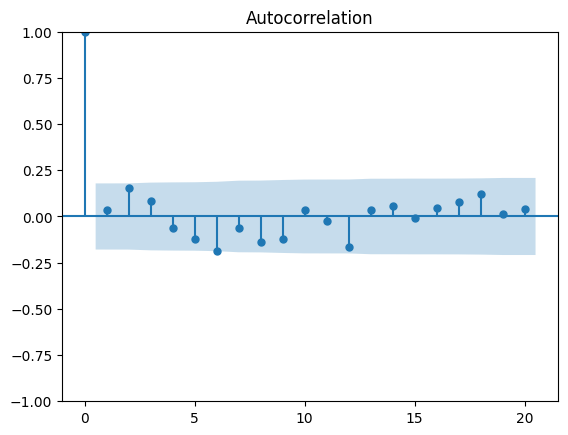

In [87]:
#Plot ACF
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(model_quad.resid, lags=20)
plt.show()

Berdasarkan plot ACF residual, sebagian besar nilai autokorelasi pada lag 1 sampai 20 berada di dalam batas kepercayaan dan berada di sekitar nol. Hal ini menunjukkan bahwa secara visual tidak terdapat autokorelasi yang kuat pada residual model regresi kuadratik. Ada beberapa lag yang nilainya cukup menonjol, terutama pada lag 6, tetapi secara umum polanya masih berada di sekitar nol dan tidak membentuk pola tertentu.

In [88]:
#Uji Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(model_quad.resid, lags=19, return_df=True)
print(ljung_box)

      lb_stat  lb_pvalue
1    0.165424   0.684211
2    3.074712   0.214949
3    3.984720   0.263119
4    4.450009   0.348516
5    6.359097   0.272828
6   10.877207   0.092246
7   11.399125   0.122132
8   13.880195   0.084942
9   15.772741   0.071782
10  15.920378   0.101934
11  16.007238   0.140862
12  19.620862   0.074607
13  19.793967   0.100468
14  20.203479   0.123856
15  20.211206   0.163979
16  20.531439   0.197232
17  21.453599   0.206655
18  23.522866   0.171289
19  23.550876   0.213948


H0: tidak terdapat autokorelasi pada residual

H1: terdapat autokorelasi pada residual

Berdasarkan uji Ljung-Box, seluruh nilai p-value pada lag 1 sampai dengan lag 19 lebih besar dari 0,05, maka gagal tolak H0. Artinya, tidak terdapat cukup bukti adanya autokorelasi yang signifikan pada residual, sehingga asumsi tidak adanya autokorelasi pada model regresi kuadratik terpenuhi.

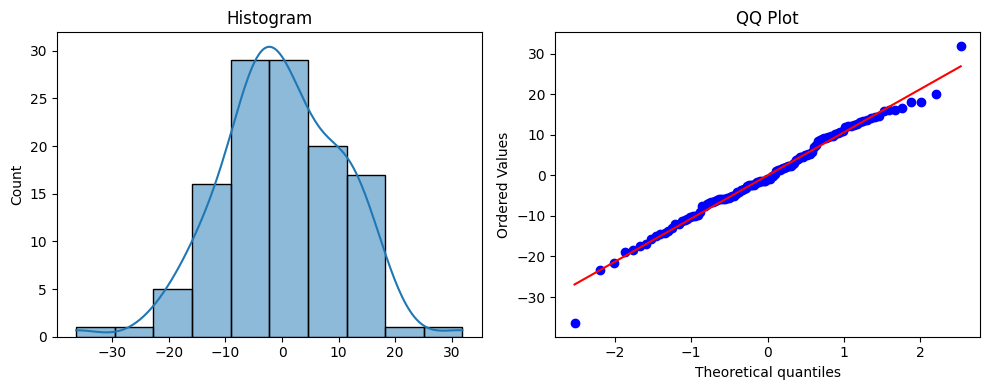

In [89]:
#Histogram dan QQ Plot
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Histogram + garis KDE
plt.subplot(1,2,1)
sns.histplot(model_quad.resid, bins=10, kde=True)
plt.title("Histogram")

# QQ Plot
plt.subplot(1,2,2)
stats.probplot(model_quad.resid, dist="norm", plot=plt)
plt.title("QQ Plot")

plt.tight_layout()
plt.show()

Berdasarkan histogram dan QQ Plot, residual secara visual terlihat mendekati distribusi normal. Hal ini terlihat dari bentuk histogram yang cukup simetris dan sebagian besar titik pada QQ Plot berada di sekitar garis diagonal. Meskipun terdapat sedikit penyimpangan pada bagian ujung, secara umum tidak terlihat penyimpangan yang besar dari distribusi normal.

In [90]:
#Shapiro Wilk
shapiro_stat, shapiro_p = stats.shapiro(model_quad.resid)

print(f"P-value Shapiro-Wilk: {shapiro_p:.4f}")

P-value Shapiro-Wilk: 0.5009


H0 : residual berdistribusi normal

H1 : residual tidak berdistribusi normal

Berdasarkan uji Shapiro-Wilk diperoleh p-value sebesar 0,5009 > 0,05, maka gagal menolak H0. Artinya, residual dapat dianggap berdistribusi normal, sehingga asumsi normalitas residual terpenuhi.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [91]:
# Menentukan parameter simulasi
np.random.seed(1047)
n_periods = 120
beta0, beta1, beta2=50+47,-25*47, -2*47
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


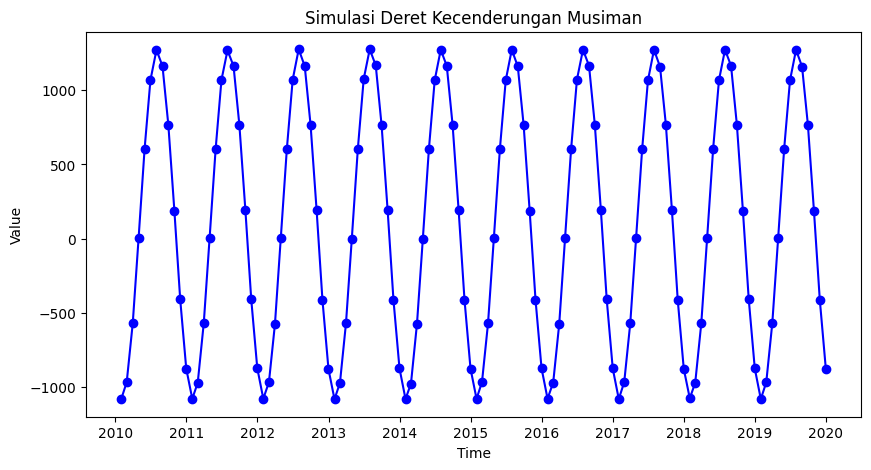

In [92]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

Berdasarkan plot di atas, deret menunjukkan pola musiman yang berulang secara teratur dengan periode 12. Pola naik dan turun terlihat hampir sama pada setiap siklus, serta tidak menunjukkan adanya tren meningkat atau menurun dalam jangka panjang. Nilai puncak dan lembah pada setiap siklus juga relatif sama, sehingga besar fluktuasinya terlihat cukup stabil dari waktu ke waktu. Hal ini menunjukkan bahwa deret memiliki pola musiman yang konsisten.

In [93]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [94]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [95]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [96]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.641e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.33e-276
Time:                        16:18:59   Log-Likelihood:                -255.74
No. Observations:                 120   AIC:                             535.5
Df Residuals:                     108   BIC:                             568.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari    -1077.7840      0.680  -1586.120      0.0

Bagaimana interpretasi dari hasil tersebut?

Berdasarkan hasil regresi, terlihat adanya pola musiman yang jelas pada data. Karena model dipasang tanpa intersep, koefisien setiap bulan menunjukkan rata-rata nilai deret pada bulan tersebut. Nilai terendah terjadi pada bulan Januari sebesar −1077,784, kemudian meningkat hingga mencapai nilai tertinggi pada bulan Juli sebesar 1271,792, lalu kembali menurun hingga Desember.Pola ini menunjukkan pola naik turun yang berulang setiap 12 bulan.
Kemudian, seluruh koefisien bulan memiliki p-value kurang dari 0,05, artinya koefisien signifikan.
Nilai Durbin-Watson sebesar 1,914 mendekati 2,menunjukkan bahwa tidak terdapat autokorelasi residual yang kuat. Sehingga berdasarkan hasil regresi dapat disimpulkan  terdapat pola musiman dengan periode 12 bulan.


In [97]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

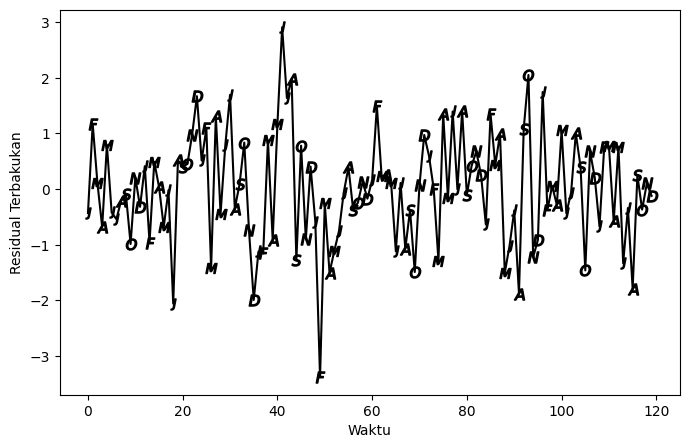

In [98]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


Pada plot residual terbakukan terhadap waktu di atas,residual terlihat menyebar di sekitar garis nol dan tidak membentuk pola tertentu dari waktu ke waktu. Tidak terlihat pola musiman yang jelas pada residual, sehingga pola musiman utama pada data sudah cukup ditangkap oleh model. Namun, terdapat beberapa residual yang cukup ekstrem pada periode tertentu, baik positif maupun negatif.

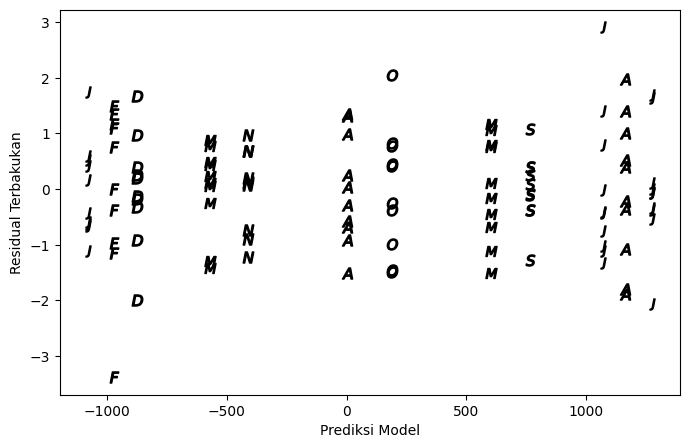

In [99]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

Pada plot residual terbakukan terhadap nilai prediksi model di atas, residual terlihat tersebar di sekitar nol dan tidak menunjukkan pola naik, turun, atau bentuk tertentu. Hal ini menunjukkan bahwa secara visual tidak terdapat pola sistematis yang tersisa pada residual. Penyebaran residual pada beberapa nilai prediksi terlihat sedikit berbeda, tetapi tidak tampak pola melebar atau menyempit yang jelas.

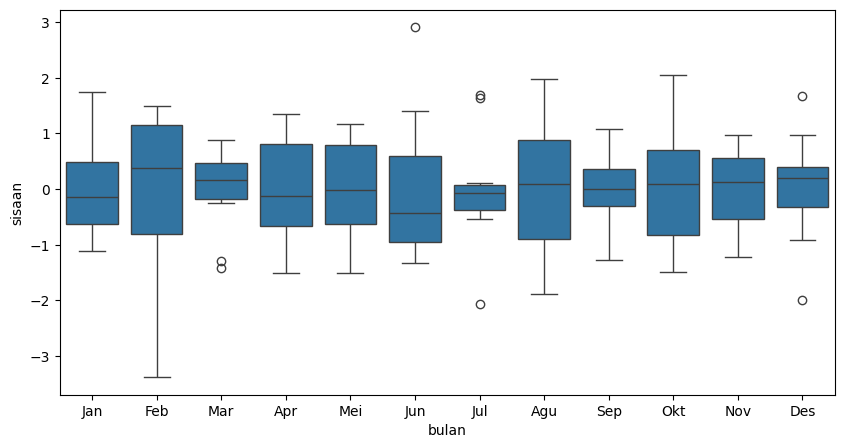

In [100]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Pada boxplot residual berdasarkan bulan, median/nilai tengah residual pada sebagian besar bulan berada di sekitar nilai nol. Hal ini menunjukkan bahwa model cukup baik dalam menangkap perbedaan pola antarbulan. Namun, lebar boxplot pada setiap bulan tidak sama persis dan terdapat beberapa pencilan pada beberapa bulan tertentu seperti bulan Maret, Juni, Juli, dan Desember. Sehingga dapat disimpulkan secara visual variasi residual antarbulan terlihat cukup stabil, meskipun tidak sepenuhnya sama.

Bagaimana interpretasi Anda terhadap tiga plot di atas?

Berdasarkan ketiga plot di atas, secara umum residual menyebar di sekitar nol dan tidak menunjukkan pola tertentu terhadap waktu, nilai prediksi, ataupun bulan. Pola musiman juga sudah tidak terlihat jelas pada residual, sehingga model dapat dikatakan cukup baik dalam menangkap pola musiman pada data. Namun, terdapat beberapa pencilan dan perbedaan penyebaran residual antarbulan, secara keseluruhan tidak terlihat adanya pola sistematis yang kuat pada residual.


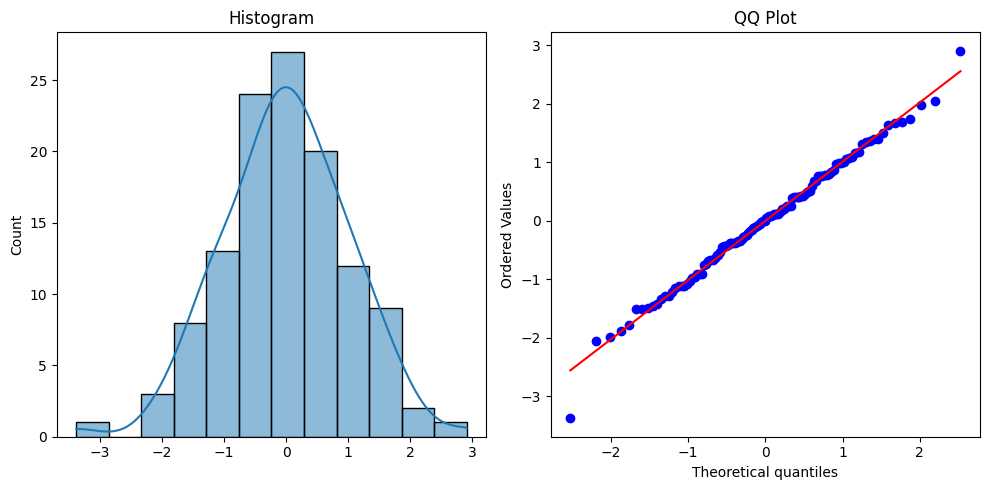

In [101]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Berdasarkan histogram dan QQ Plot, secara visual residual terlihat mendekati distribusi normal. Histogram menunjukkan bentuk yang cukup simetris, sedangkan sebagian besar titik pada QQ Plot berada di sekitar garis diagonal, walaupun terdapat sedikit penyimpangan pada bagian ujung.





Hitunglah statistik uji untuk mengecek asumsi model

In [102]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [103]:
# Uji Breusch-Pagan
X_bp = sm.add_constant(musiman.model.exog)

bp = het_breuschpagan(musiman.resid, X_bp)
print("P-value Breusch-Pagan:", bp[1])

P-value Breusch-Pagan: 0.4284603800195592


H0 : asumsi homoskedastisitas terpenuhi

H1 : asumsi homoskedastisitas tidak terpenuhi

Berdasarkan uji Breusch-Pagan diperoleh nilai p-value sebesar 0,4285 > 0,05, maka gagal menolak H0. Artinya, tidak terdapat cukup bukti adanya heteroskedastisitas, sehingga asumsi homoskedastisitas terpenuhi.

In [104]:
#Uji Ljung Box
ljung_box = acorr_ljungbox(
    musiman.resid,
    lags=19,
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
1    0.217537   0.640923
2    3.118554   0.210288
3    3.822837   0.281241
4    3.978447   0.408931
5    5.721525   0.334265
6    9.505860   0.147063
7   10.035633   0.186563
8   11.874377   0.156898
9   14.777684   0.097226
10  14.832876   0.138275
11  14.875834   0.188252
12  22.472284   0.032555
13  22.747317   0.044810
14  23.082097   0.058947
15  23.128521   0.081449
16  24.021928   0.089027
17  25.083420   0.092858
18  28.605768   0.053415
19  28.661297   0.071503


H0: tidak terdapat autokorelasi pada residual

H1: terdapat autokorelasi pada residual

Berdasarkan uji Ljung-Box, sebagian besar nilai p-value pada lag 1 sampai 19 lebih besar dari 0,05. Namun, pada lag 12 dan lag 13 diperoleh p-value masing-masing sebesar 0,0326 dan 0,0448 yang lebih kecil dari 0,05. Hal ini menunjukkan adanya indikasi autokorelasi pada residual hingga lag tersebut. Karena lag 12 sesuai dengan periode musiman data, hasil ini juga menunjukkan bahwa masih terdapat kemungkinan pola musiman yang belum sepenuhnya ditangkap oleh model.

In [105]:
#Uji Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(musiman.resid)

print("Shapiro-Wilk Statistic:", shapiro_stat)
print("P-value Shapiro-Wilk:", shapiro_p)

Shapiro-Wilk Statistic: 0.9943827543605666
P-value Shapiro-Wilk: 0.9159443231913921


H0 : residual berdistribusi normal

H1 : residual tidak berdistribusi normal

Berdasarkan uji Shapiro-Wilk diperoleh p-value sebesar 0,9159 > 0,05, maka gagal menolak H0. Artinya, residual dapat dianggap berdistribusi normal, sehingga asumsi normalitas residual terpenuhi.

In [106]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [107]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.641e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.33e-276
Time:                        16:19:01   Log-Likelihood:                -255.74
No. Observations:                 120   AIC:                             535.5
Df Residuals:                     108   BIC:                             568.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1077.7840      0.680  -1586.120      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Jawaban:
Berdasarkan hasil pengepasan model dengan intersep dan tanpa intersep memberikan hasil yang sama. Kedua model memiliki nilai R^2, AIC, BIC, dan Durbin-Watson yang sama. Hal ini terjadi karena kedua model menghasilkan nilai prediksi dan residual yang sama. Perbedaannya hanya terletak pada cara penulisan model dan cara membaca koefisiennya.

Pada model tanpa intersep, koefisien setiap bulan langsung menunjukkan rata-rata nilai pada bulan tersebut. Misalnya, koefisien Januari sebesar -1077,78 berarti rata-rata nilai pada bulan Januari adalah sekitar -1077,78, kemudian koefisien Februari sebesar -967,65 berarti rata-rata nilai pada bulan Februari sekitar -967,65 dan seterusnya.

Sedangkan pada model dengan intersep, koefisien menunjukkan perbedaan setiap bulan terhadap bulan acuan, yaitu Januari. Nilai intersep sebesar -1077.78 menunjukkan rata-rata nilai pada bulan Januari. Sementara koefisien bulan lainnya menunjukkan selisih rata-rata bulan tersebut terhadap Januari. Misalnya, koefisien Februari sebesar 110,13 berarti rata-rata bulan Februari sekitar 110,13 lebih tinggi dibandingkan Januari. Jadi rata-rata Februari diperoleh dari -1077,78 + 110,13 = -967,65. Kemudian koefisien pada bulan September sebesar 1843,62 berarti rata-rata bulan September sekitar 1843,62 lebih tinggi dibandingkan Januari.




Apakah model dengan intersep sudah memenuhi asumsi regresi?

Jawaban:

Berdasarkan hasil pengujian asumsi model pada code di bawah dengan intersep sudah memenuhi sebagian besar asumsi regresi. Uji Breusch-Pagan menghasilkan p-value sebesar 0,3476 yang lebih besar dari 0,05, sehingga asumsi homoskedastisitas terpenuhi. Uji Shapiro-Wilk juga menghasilkan p-value sebesar 0,9159 yang lebih besar dari 0,05, sehingga residual dapat dianggap berdistribusi normal.

Namun, pada uji Ljung-Box terdapat p-value kurang dari 0,05 pada lag 12 dan 13. Hal ini menunjukkan masih terdapat indikasi autokorelasi pada residual. Dengan demikian, model dengan intersep sudah memenuhi asumsi homoskedastisitas dan normalitas, tetapi asumsi tidak adanya autokorelasi belum sepenuhnya terpenuhi.

In [108]:
# uji asumsi model dengan intersep

In [109]:
# Uji Breusch-Pagan
bp_int = het_breuschpagan(
    musiman_int.resid,
    musiman_int.model.exog
)
print("P-value Breusch-Pagan:", bp_int[1])

P-value Breusch-Pagan: 0.34759877896667


H0 : asumsi homoskedastisitas terpenuhi

H1 : asumsi homoskedastisitas tidak terpenuhi

Berdasarkan uji Breusch-Pagan diperoleh nilai p-value sebesar 0,3476 > 0,05, maka gagal menolak H0. Artinya, tidak terdapat cukup bukti adanya heteroskedastisitas, sehingga asumsi homoskedastisitas terpenuhi.

In [110]:
# Ljung-Box
lb_int = acorr_ljungbox(
    musiman_int.resid,
    lags=19,
    return_df=True
)

print("\nLjung-Box:")
print(lb_int)


Ljung-Box:
      lb_stat  lb_pvalue
1    0.217537   0.640923
2    3.118554   0.210288
3    3.822837   0.281241
4    3.978447   0.408931
5    5.721525   0.334265
6    9.505860   0.147063
7   10.035633   0.186563
8   11.874377   0.156898
9   14.777684   0.097226
10  14.832876   0.138275
11  14.875834   0.188252
12  22.472284   0.032555
13  22.747317   0.044810
14  23.082097   0.058947
15  23.128521   0.081449
16  24.021928   0.089027
17  25.083420   0.092858
18  28.605768   0.053415
19  28.661297   0.071503


H0: tidak terdapat autokorelasi pada residual

H1: terdapat autokorelasi pada residual

Berdasarkan uji Ljung-Box, sebagian besar nilai p-value pada lag 1 sampai 19 lebih besar dari 0,05. Namun, pada lag 12 dan lag 13 diperoleh p-value masing-masing sebesar 0,0326 dan 0,0448 yang lebih kecil dari 0,05. Hal ini menunjukkan adanya indikasi autokorelasi pada residual hingga lag tersebut. Karena lag 12 sesuai dengan periode musiman data, hasil ini juga menunjukkan bahwa masih terdapat kemungkinan pola musiman yang belum sepenuhnya ditangkap oleh model.

In [111]:
# Shapiro-Wilk
shapiro_stat_int, shapiro_p_int = stats.shapiro(
    musiman_int.resid
)

print("\nShapiro-Wilk:")
print("Statistic:", shapiro_stat_int)
print("P-value:", shapiro_p_int)


Shapiro-Wilk:
Statistic: 0.9943827543605694
P-value: 0.9159443231915702


H0 : residual berdistribusi normal

H1 : residual tidak berdistribusi normal

Berdasarkan uji Shapiro-Wilk diperoleh p-value sebesar 0,9159 > 0,05, maka gagal menolak H0. Artinya, residual dapat dianggap berdistribusi normal, sehingga asumsi normalitas residual terpenuhi.

## Kecenderungan Linear dan Musiman

In [112]:
# Parameter
np.random.seed(1047)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5*47, 10*47 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


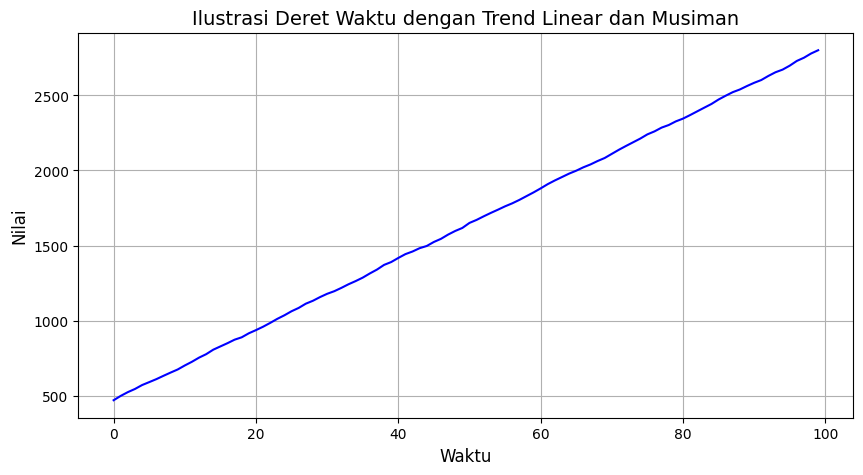

In [113]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [114]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [115]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [116]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.618e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          6.64e-213
Time:                        16:19:01   Log-Likelihood:                -215.73
No. Observations:                 100   AIC:                             457.5
Df Residuals:                      87   BIC:                             491.3
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      470.3194      0.836    562.542      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

Pada model ini memenggabungkan kecenderungan linear dan musiman, koefisien bulan menunjukkan perbedaan pola musiman, sedangkan koefisien period menunjukkan perubahan nilai deret dari waktu ke waktu.

Berdasarkan hasil regresi, koefisien period sebesar 27,501 menunjukkan bahwa setiap bertambah satu periode, nilai deret akan meningkat sekitar 27,501. Hal ini menunjukkan adanya kecenderungan linear yang meningkat dari waktu ke waktu.

Sementara itu, koefisien pada masing-masing bulan menunjukkan adanya perbedaan pola musiman antarbulan. Misalnya, koefisien Maret sebesar 475,859 lebih tinggi dibandingkan Januari sebesar 470,319, sehingga efek musiman bulan Maret sekitar 5,54 lebih tinggi dibandingkan Januari. Dengan demikian, model menunjukkan adanya kecenderungan linear yang meningkat serta pola musiman yang berbeda pada setiap bulan.


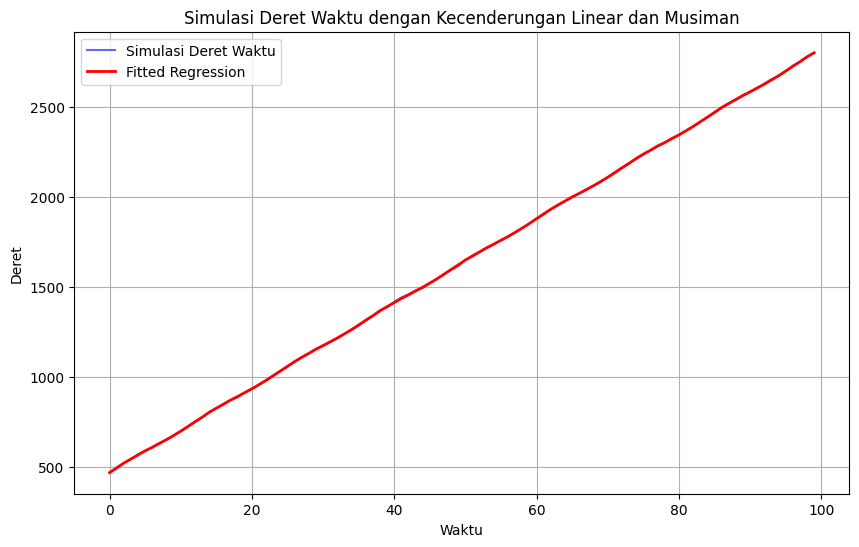

In [117]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi linear dengan komponen musiman
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

Jawaban:

Berdasarkan uji asumsi model yang dilakukan dibawah ini, model tidak menunjukkan adanya pelanggaran asumsi. Plot Residuals vs Fitted Values menunjukkan residual menyebar secara acak di sekitar garis nol dan tidak membentuk pola tertentu. Uji Breusch-Pagan menghasilkan p-value sebesar 0,4598 yang lebih besar dari 0,05, sehingga asumsi homoskedastisitas terpenuhi. Hasil uji Ljung-Box pada lag 1 sampai 19 juga seluruhnya memiliki p-value lebih besar dari 0,05, sehingga tidak terdapat autokorelasi yang signifikan pada residual. Selain itu, histogram dan QQ Plot menunjukkan residual mendekati distribusi normal. Hal ini diperkuat oleh uji Shapiro-Wilk dengan p-value sebesar 0,7764 yang lebih besar dari 0,05, sehingga asumsi normalitas residual terpenuhi. Dengan demikian, secara umum model telah memenuhi asumsi regresi dan tidak terdapat pelanggaran asumsi.

In [118]:
# uji asumsi model

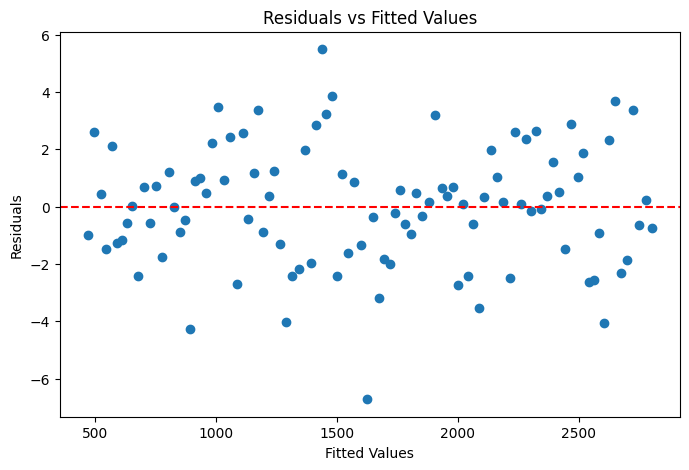

In [119]:
# Plot Residual vs Fitted Values
plt.figure(figsize=(8,5))
plt.scatter(model_mix.fittedvalues, model_mix.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

Berdasarkan plot Residuals vs Fitted Values, titik-titik residual menyebar secara acak di sekitar garis nol dan tidak membentuk pola tertentu. Hal ini menunjukkan bahwa bentuk model sudah cukup sesuai.

In [120]:
#Uji Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Januari dihilangkan, kemudian ditambahkan konstanta
X_bp = sm.add_constant(season.iloc[:, 1:])

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model_mix.resid, X_bp)

print(f"P-value Breusch-Pagan: {bp_test[1]:.4f}")

P-value Breusch-Pagan: 0.4598


H0 : asumsi homoskedastisitas terpenuhi

H1 : asumsi homoskedastisitas tidak terpenuhi

Berdasarkan uji Breusch-Pagan diperoleh p-value sebesar 0,4598 > 0,05, maka gagal menolak H0. Artinya, tidak terdapat cukup bukti adanya heteroskedastisitas, sehingga asumsi homoskedastisitas pada model dapat dikatakan terpenuhi.

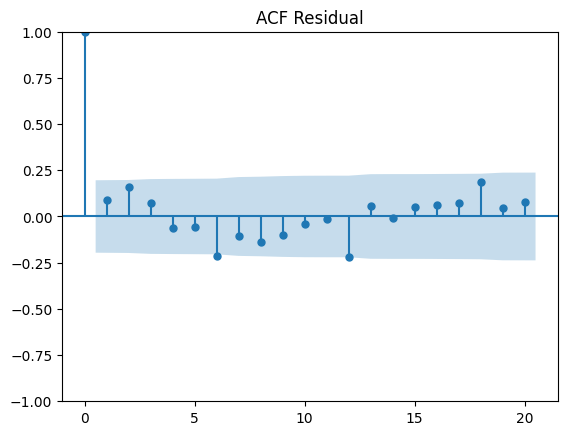

In [121]:
#Plot ACF Residual
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(model_mix.resid, lags=20)
plt.title('ACF Residual')
plt.show()

Berdasarkan plot ACF residual, sebagian besar nilai autokorelasi pada lag 1 sampai 20 berada di dalam batas kepercayaan dan berada di sekitar nol. Hal ini menunjukkan bahwa secara umum tidak terlihat autokorelasi yang kuat pada residual. Namun, terdapat beberapa lag terutama pada lag 6 dan lag 12, yang nilainya berada sangat dekat atau sedikit melewati batas kepercayaan.



In [122]:
#Uji Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    model_mix.resid,
    lags=19,
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
1    0.795595   0.372414
2    3.446209   0.178511
3    3.970674   0.264648
4    4.376323   0.357465
5    4.757856   0.446141
6    9.830293   0.131983
7   11.050900   0.136414
8   13.184281   0.105664
9   14.295209   0.112205
10  14.503155   0.151253
11  14.526282   0.205227
12  20.042091   0.066294
13  20.385921   0.085996
14  20.392026   0.118258
15  20.721127   0.145979
16  21.165599   0.172233
17  21.829627   0.191360
18  26.195970   0.095361
19  26.483870   0.117262


H0: tidak terdapat autokorelasi pada residual



H1: terdapat autokorelasi pada residual



Berdasarkan uji Ljung-Box, seluruh nilai p-value pada lag 1 sampai dengan lag 19 lebih besar dari 0,05, maka gagal tolak H0. Artinya, tidak terdapat cukup bukti adanya autokorelasi yang signifikan pada residual, sehingga asumsi tidak adanya autokorelasi pada model terpenuhi.

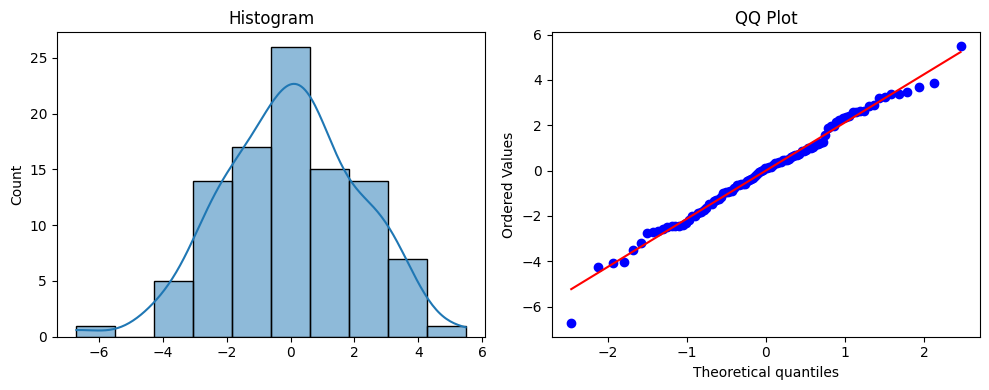

In [123]:
#Histogram dan QQ Plot
import seaborn as sns
import scipy.stats as stats

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(model_mix.resid, bins=10, kde=True)
plt.title('Histogram')

plt.subplot(1,2,2)
stats.probplot(model_mix.resid, dist='norm', plot=plt)
plt.title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan histogram dan QQ Plot, residual secara visual terlihat mendekati distribusi normal. Hal ini terlihat dari bentuk histogram yang cukup simetris dan sebagian besar titik pada QQ Plot berada di sekitar garis diagonal. Meskipun terdapat sedikit penyimpangan pada bagian ujung, secara umum tidak terlihat penyimpangan yang besar dari distribusi normal.  

In [124]:
#Uji Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(model_mix.resid)

print("Shapiro-Wilk Statistic:", shapiro_stat)
print(f"P-value Shapiro-Wilk: {shapiro_p:.4f}")

Shapiro-Wilk Statistic: 0.991401800125553
P-value Shapiro-Wilk: 0.7764


H0 : residual berdistribusi normal



H1 : residual tidak berdistribusi normal



Berdasarkan uji Shapiro-Wilk diperoleh p-value sebesar 0,7764 > 0,05, maka gagal menolak H0. Artinya, residual dapat dianggap berdistribusi normal, sehingga asumsi normalitas residual terpenuhi.

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [125]:
print(df.columns)

Index(['Time', 'Value', 'Time_Numeric'], dtype='object')


In [126]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

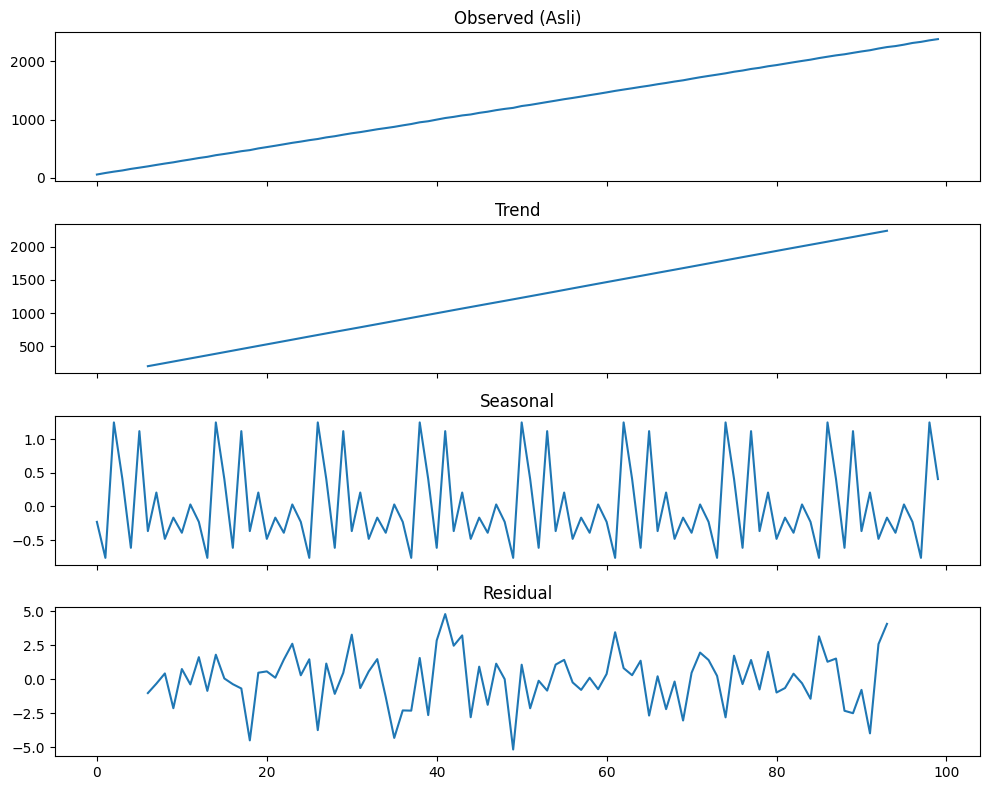

In [127]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi deret waktu dibagi menjadi komponen tren, musiman, dan residual. Pada data asli terlihat nilai deret berfluktuasi dari waktu ke waktu. Komponen tren menunjukkan perubahan yang relatif perlahan yaitu meningkat, menurun, kemudian meningkat kembali, sehingga tidak terlihat kecenderungan naik atau turun yang terus-menerus.

Komponen musiman menunjukkan pola yang berulang dengan bentuk dan besar fluktuasi yang relatif sama pada setiap periode. Hal ini menunjukkan adanya pola musiman yang cukup jelas pada data. Sementara itu, komponen residual terlihat berfluktuasi di sekitar nol dan tidak membentuk pola tertentu, meskipun terdapat beberapa nilai yang cukup ekstrem.


In [128]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

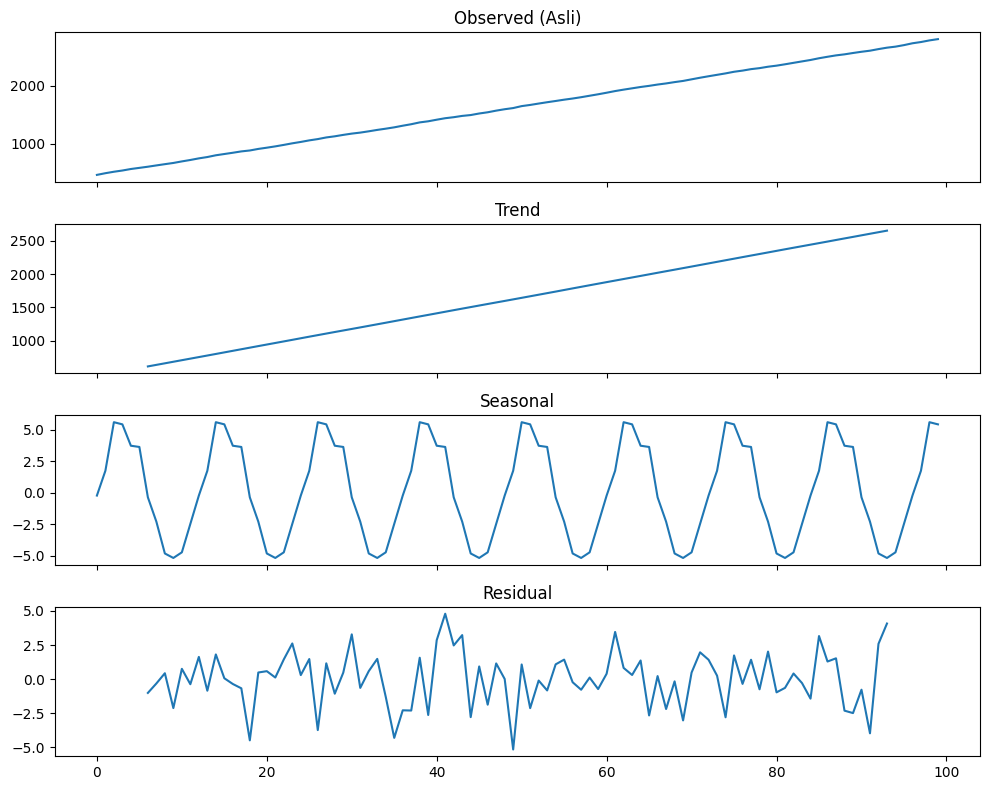

In [129]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi, deret menunjukkan kecenderungan meningkat secara jelas dari waktu ke waktu disertai pola musiman yang berulang. Komponen tren memperlihatkan kenaikan yang hampir linear hingga akhir periode. Komponen musiman menunjukkan pola naik dan turun yang relatif sama pada setiap siklus dengan besar fluktuasi yang cenderung tetap. Sementara itu, komponen residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola tertentu. Sehingga, deret dipengaruhi oleh komponen tren dan musiman, sedangkan sisanya merupakan variasi acak.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [130]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1047)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05*47, 10*47 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

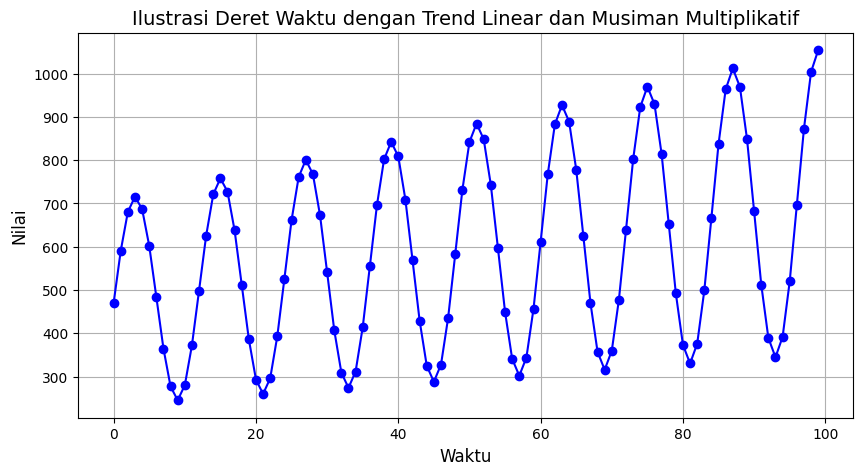

In [131]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [132]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

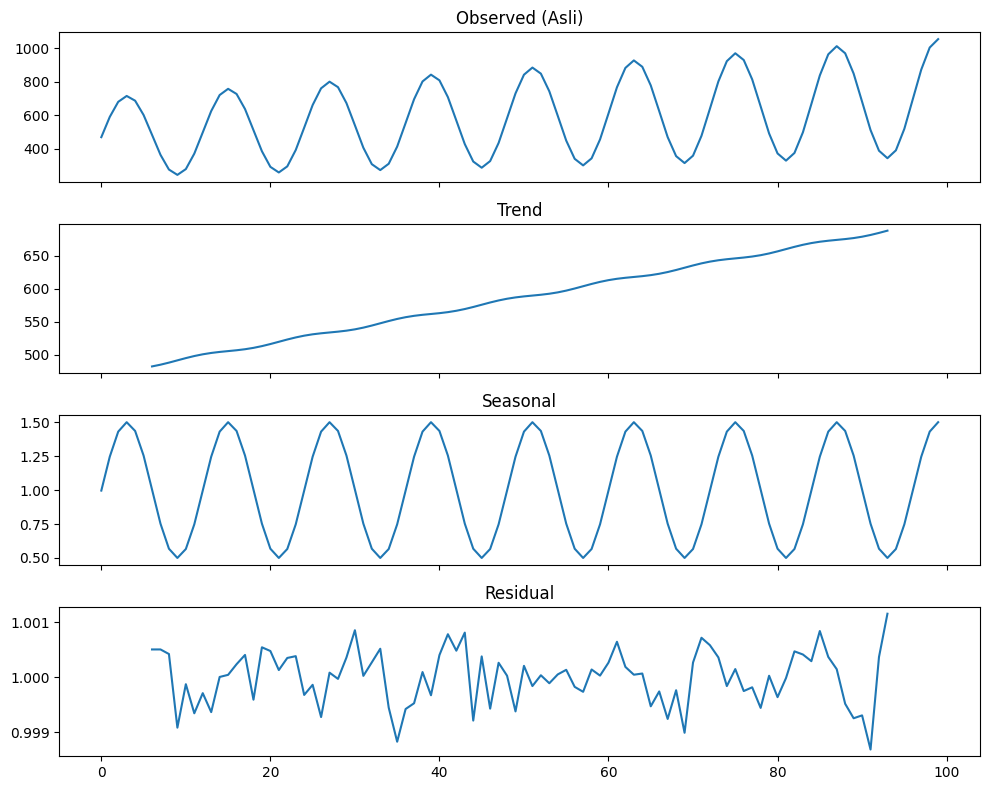

In [133]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

Berdasarkan hasil dekomposisi, deret asli menunjukkan adanya tren yang meningkat serta pola naik turun yang berulang dari waktu ke waktu. Pada komponen tren, nilai deret mengalami kenaikan secara bertahap hingga akhir periode. Pada deret asli, besarnya naik turun data cenderung semakin besar ketika tingkat deret meningkat, sehingga pola tersebut sesuai dengan dekomposisi multiplikatif. Komponen musiman menunjukkan pola yang berulang pada setiap siklus, sedangkan residual sebagian besar berada di sekitar nilai 1 dan tidak menunjukkan pola yang jelas. Oleh karena itu, perubahan pada deret terutama dipengaruhi oleh komponen tren dan musiman, sementara variasi yang tidak dapat dijelaskan  relatif kecil.


In [134]:
# Parameter
np.random.seed(1047)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

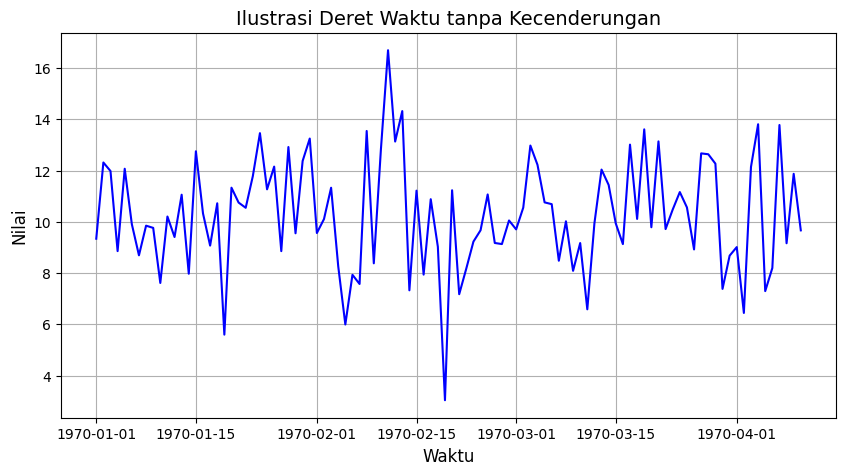

In [135]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

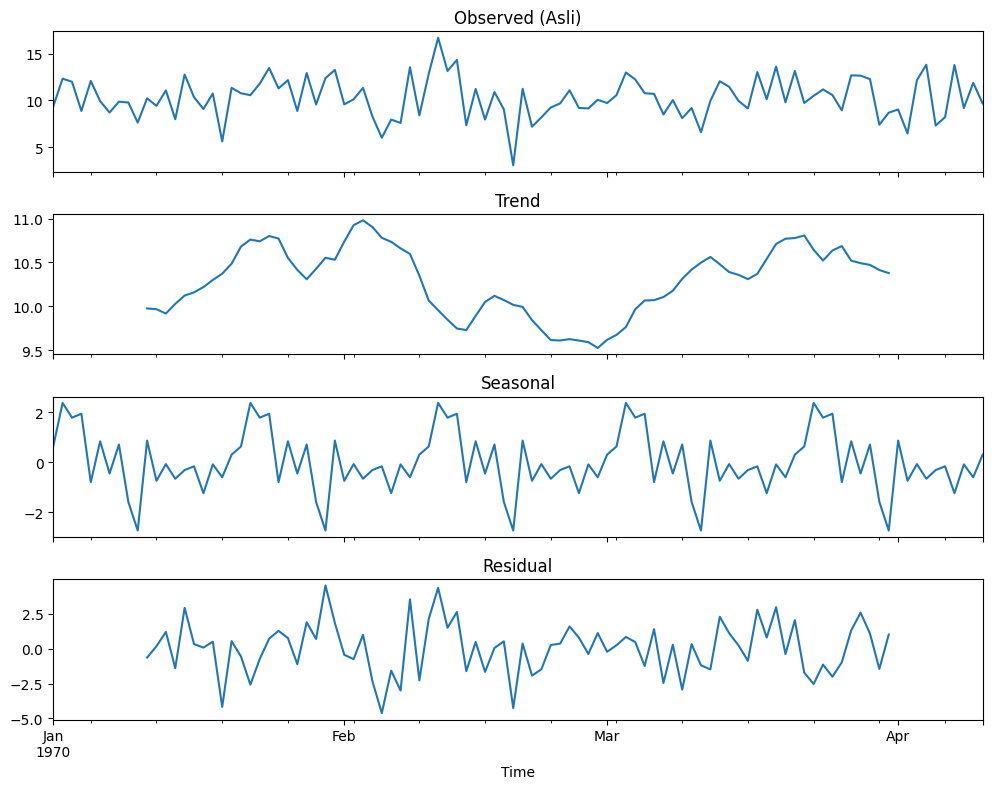

In [136]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

Berdasarkan hasil dekomposisi, deret asli menunjukkan fluktuasi dari waktu ke waktu tanpa adanya kecenderungan naik atau turun yang kuat. Komponen tren mengalami perubahan secara perlahan, sedangkan komponen musiman menunjukkan pola yang berulang secara teratur. Residual terlihat menyebar di sekitar nilai nol dan tidak membentuk pola yang jelas.